# Pair Trading

## Sync-Pair

In [173]:
import numpy as np

def create_synchronized_pair_data(total_frames=200):
    """
    Generates two perfectly correlated asset prices (Asset A and Asset B).
    They share the exact same phase and frequency but trade at different baseline heights.
    """
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # Asset A: Cycles around a baseline of 2.0 with an amplitude of 1.0
    asset_a = 2.0 + 1.0 * np.sin(x_space)

    # Asset B: Cycles around a baseline of 0.0 with the exact same amplitude and phase
    asset_b = 0.0 + 1.0 * np.sin(x_space)

    return x_space, asset_a, asset_b


In [174]:
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_pair_trading_market(x_space, asset_a_data, asset_b_data, title="Pair Trading Setup", interval=20):
    """
    High-performance live drawing engine optimized for twin asset data streams.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    fig, ax = plt.subplots(figsize=(12, 5))
    sleep_time = interval / 1000.0

    try:
        while True:
            ax.clear()
            ax.set_xlim(0, max_x)
            # Find global min and max across both assets to set perfect Y boundaries
            y_min = min(min(asset_a_data), min(asset_b_data)) - 0.5
            y_max = max(max(asset_a_data), max(asset_b_data)) + 0.5
            ax.set_ylim(y_min, y_max)
            ax.set_title(title, fontsize=12)
            ax.grid(True, linestyle="--", alpha=0.3)

            # Initialize the pair of lines and their leading brush tips
            line_a, = ax.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax.plot([], [], color="navy", marker="o", markersize=6)

            line_b, = ax.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax.plot([], [], color="darkorange", marker="o", markersize=6)

            ax.legend(loc="upper right")

            x_history, a_history, b_history = [], [], []

            for i in range(total_frames):
                current_x = x_space[i]
                current_a = asset_a_data[i]
                current_b = asset_b_data[i]

                x_history.append(current_x)
                a_history.append(current_a)
                b_history.append(current_b)

                # Push twin data updates to their respective graphic layers
                line_a.set_data(x_history, a_history)
                tip_a.set_data([current_x], [current_a])

                line_b.set_data(x_history, b_history)
                tip_b.set_data([current_x], [current_b])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            time.sleep(0.8)

    except KeyboardInterrupt:
        print("\n[INFO] Pair trading simulation stopped by user.")
    finally:
        plt.close(fig)


In [175]:
# 1. Compute the twin synchronous asset vectors
x_pair, asset_A, asset_B = create_synchronized_pair_data(total_frames=200)

# 2. Launch the twin stream animation in VS Code
stream_pair_trading_market(x_pair, asset_A, asset_B, title="Co-integrated Pair Trading Baseline: Perfect Correlation", interval=15)



[INFO] Pair trading simulation stopped by user.


## Spread

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_pair_trading_with_spread(x_space, asset_a_data, asset_b_data, title="Pair Trading Dashboard", interval=20):
    """
    High-performance multi-panel live drawing engine for pair trading.
    Fixed the spread axis limit bug by calculating dynamic Y boundaries for Panel 2.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]
    spread_data = np.array(asset_a_data) - np.array(asset_b_data)
    sleep_time = interval / 1000.0

    try:
        while True:
            # 1. PREPARE THE FIGURE FRAMEWORK ONCE
            fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

            # Setup Panel 1 (Prices)
            ax1.set_xlim(0, max_x)
            y_min_prices = min(min(asset_a_data), min(asset_b_data)) - 0.5
            y_max_prices = max(max(asset_a_data), max(asset_b_data)) + 0.5
            ax1.set_ylim(y_min_prices, y_max_prices)
            ax1.set_title(title, fontsize=12, fontweight="bold")
            ax1.set_ylabel("Asset Prices ($)")
            ax1.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
            ax1.legend(loc="upper right")

            # Setup Panel 2 (Spread)
            ax2.set_xlim(0, max_x)
            spread_mean = np.mean(spread_data)

            # FIX: Calculate exact dynamic Y limits for the spread based on actual data bounds
            y_min_spread = min(spread_data) - 0.5
            y_max_spread = max(spread_data) + 0.5
            ax2.set_ylim(y_min_spread, y_max_spread)

            ax2.set_title("Statistical Arbitrage: Price Spread (A - B)", fontsize=11)
            ax2.set_xlabel("Time (Cycles)")
            ax2.set_ylabel("Spread Deviation")
            ax2.grid(True, linestyle="--", alpha=0.3)
            ax2.axhline(spread_mean, color="black", linestyle="-", alpha=0.4)

            line_spread, = ax2.plot([], [], color="purple", linewidth=2, label="Current Spread")
            tip_spread, = ax2.plot([], [], color="purple", marker="o", markersize=6)
            ax2.legend(loc="upper right")

            fig.tight_layout()

            x_hist, a_hist, b_hist, s_hist = [], [], [], []

            # 2. FAST ANIMATION LOOP
            for i in range(total_frames):
                current_x = x_space[i]
                current_a = asset_a_data[i]
                current_b = asset_b_data[i]
                current_s = spread_data[i]

                x_hist.append(current_x)
                a_hist.append(current_a)
                b_hist.append(current_b)
                s_hist.append(current_s)

                # BLIT REFRESH
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([current_x], [current_a])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([current_x], [current_b])

                line_spread.set_data(x_hist, s_hist)
                tip_spread.set_data([current_x], [current_s])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            time.sleep(0.8)
            plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Pair trading simulation stopped by user.")
    finally:
        plt.close(fig)


In [185]:
# 1. Reuse our perfect parallel sinus data vectors
x_pair, asset_A, asset_B = create_synchronized_pair_data(total_frames=200)

# 2. Launch the twin-panel interface
stream_pair_trading_with_spread(x_pair, asset_A, asset_B, title="Co-integrated Pair Baseline Analysis", interval=15)



[INFO] Pair trading simulation stopped by user.


## Dephase

In [3]:
import numpy as np

def create_out_of_phase_pair_data(total_frames=200):
    """
    Generates two perfectly out-of-phase asset prices (Asset A and Asset B).
    They share the same frequency but move in exact opposite directions.
    """
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # Asset A: Cycles around a baseline of 2.0
    asset_a = 2.0 + 1.0 * np.sin(x_space)

    # Asset B: Cycles around a baseline of 0.0 but with a negative sine
    # to create a perfect 180-degree phase inversion
    asset_b = 0.0 - 1.0 * np.sin(x_space)

    return x_space, asset_a, asset_b


In [151]:
# 1. Compute the out-of-phase twin asset vectors
x_pair, asset_A_out, asset_B_out = create_out_of_phase_pair_data(total_frames=200)

# 2. Launch the twin-panel stream animation
stream_pair_trading_with_spread(
    x_pair, asset_A_out, asset_B_out,
    title="Pair Trading Analysis: Perfect Out-of-Phase Inversion",
    interval=15
)



[INFO] Pair trading simulation stopped by user.


## Spread Z-score

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_pair_trading_with_zscore(x_space, asset_a_data, asset_b_data, title="Pair Trading Strategy", interval=20):
    """
    High-performance live drawing engine with centered-reduced Spread (Z-Score).
    Simulates entry at +/-0.75 thresholds and exit at 0.0 with persistent trade colors.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]
    sleep_time = interval / 1000.0

    # 1. PRE-COMPUTE THE CENTERED-REDUCED SPREAD (Z-SCORE)
    raw_spread = np.array(asset_a_data) - np.array(asset_b_data)
    spread_mean = np.mean(raw_spread)
    spread_std = np.std(raw_spread)

    # To prevent division by zero in perfectly flat scenarios
    if spread_std == 0:
        spread_std = 1.0

    zscore_data = (raw_spread - spread_mean) / spread_std

    try:
        while True:
            # 2. SETUP GRAPHIC LAYOUT ONCE
            fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

            # Panel 1: Prices Setup
            ax1.set_xlim(0, max_x)
            y_min_prices = min(min(asset_a_data), min(asset_b_data)) - 0.5
            y_max_prices = max(max(asset_a_data), max(asset_b_data)) + 0.5
            ax1.set_ylim(y_min_prices, y_max_prices)
            ax1.set_title(title, fontsize=12, fontweight="bold")
            ax1.set_ylabel("Asset Prices ($)")
            ax1.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
            ax1.legend(loc="upper right")

            # Panel 2: Z-Score Spread Setup
            ax2.set_xlim(0, max_x)
            ax2.set_ylim(-2.5, 2.5) # Standard fixed boundaries for a normalized Z-score
            ax2.set_title("Statistical Arbitrage: Centered-Reduced Spread (Z-Score)", fontsize=11)
            ax2.set_xlabel("Time (Cycles)")
            ax2.set_ylabel("Z-Score")
            ax2.grid(True, linestyle="--", alpha=0.3)

            # Fixed standardized thresholds
            ax2.axhline(0.75, color="gray", linestyle="--", alpha=0.7)
            ax2.axhline(0.0, color="black", linestyle="-", alpha=0.5)
            ax2.axhline(-0.75, color="gray", linestyle="--", alpha=0.7)

            line_zscore, = ax2.plot([], [], color="purple", linewidth=2)
            tip_zscore, = ax2.plot([], [], color="purple", marker="o", markersize=6)

            fig.tight_layout()

            # Historical storage counters
            x_hist, a_hist, b_hist, z_hist = [], [], [], []
            active_fill = None

            in_short_trade, in_long_trade = False, False
            trade_x, trade_z = [], []

            # 3. INTERACTIVE SIMULATION LOOP
            for i in range(total_frames):
                current_x = x_space[i]
                current_a = asset_a_data[i]
                current_b = asset_b_data[i]
                current_z = zscore_data[i]

                x_hist.append(current_x)
                a_hist.append(current_a)
                b_hist.append(current_b)
                z_hist.append(current_z)

                # --- PAIR TRADING STRATEGY LOGIC ---
                if not in_short_trade and not in_long_trade:
                    if current_z >= 0.75:
                        in_short_trade = True
                        trade_x, trade_z = [current_x], [current_z]
                    elif current_z <= -0.75:
                        in_long_trade = True
                        trade_x, trade_z = [current_x], [current_z]

                elif in_short_trade or in_long_trade:
                    trade_x.append(current_x)
                    trade_z.append(current_z)

                    # EXIT CONDITION: Z-score returns to the mean axis (0.0)
                    if (in_short_trade and current_z <= 0.0) or (in_long_trade and current_z >= 0.0):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        # Permanent background bake
                        ax2.fill_between(trade_x, trade_z, 0, color=fill_color, alpha=0.5)
                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_z = [], []
                        active_fill = None

                # --- RENDERING ENGINE CONTEXT ---
                if active_fill is not None:
                    active_fill.remove()
                    active_fill = None

                if len(trade_x) > 0:
                    fill_color = "coral" if in_short_trade else "lightgreen"
                    active_fill = ax2.fill_between(trade_x, trade_z, 0, color=fill_color, alpha=0.5)

                # Update line models vector inputs
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([current_x], [current_a])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([current_x], [current_b])

                line_zscore.set_data(x_hist, z_hist)
                tip_zscore.set_data([current_x], [current_z])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            time.sleep(0.8)
            plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Pair trading simulation stopped safely.")
    finally:
        plt.close(fig)


In [6]:
# 1. Compute the out-of-phase asset profiles
x_pair, asset_A_out, asset_B_out = create_out_of_phase_pair_data(total_frames=200)

# 2. Launch the dynamic dashboard
stream_pair_trading_with_zscore(
    x_pair, asset_A_out, asset_B_out,
    title="Z-Score Arbitrage: Out-of-Phase Simulation",
    interval=15
)



[INFO] Pair trading simulation stopped safely.


## Stochastic Pairs

In [186]:
import numpy as np

def create_stochastic_pair_data(total_frames=200):
    """
    Generates two co-integrated assets using a persistent stochastic AR(1) process.
    Asset B moves randomly, and Asset A follows it with a structural spread
    plus temporary mean-reverting deviations.
    """
    np.random.seed(42)
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # 1. Generate Asset B as a clean, wide stochastic wave
    asset_b = np.zeros(total_frames)
    phi = 0.96
    shock_volatility = 0.15

    for t in range(1, total_frames):
        asset_b[t] = phi * asset_b[t-1] + np.random.normal(0, shock_volatility)

    # Shift Asset B upward so it trades around a positive baseline (e.g., $10)
    asset_b += 10.0

    # 2. Generate the temporary deviations (the spread noise)
    # This deviation must be mean-reverting so the pair stays co-integrated
    deviation = np.zeros(total_frames)
    phi_dev = 0.85 # Faster pull-back to the mean for the spread
    shock_dev = 0.12

    for t in range(1, total_frames):
        deviation[t] = phi_dev * deviation[t-1] + np.random.normal(0, shock_dev)

    # 3. Build Asset A: Asset B + Structural Spread ($3.0) + Temporary Deviation
    asset_a = asset_b + 3.0 + deviation

    return x_space, asset_a, asset_b


In [187]:
# 1. Compute the stochastic co-integrated pair data
x_stoch_pair, asset_A_rand, asset_B_rand = create_stochastic_pair_data(total_frames=250)

# 2. Launch the dynamic pair trading simulator
stream_pair_trading_with_zscore(
    x_stoch_pair, asset_A_rand, asset_B_rand,
    title="Statistical Arbitrage: Trading Co-integrated AR(1) Stochastic Assets",
    interval=12
)



[INFO] Pair trading simulation stopped safely.


## Z-score stop loss

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_pair_trading_scenarios(x_space, asset_a_data, asset_b_data, title="Pair Trading Strategy Analysis", interval=20):
    """
    High-performance live drawing engine simulating standard pair trading conditions.
    Keeps a persistent visual history of all past stop-loss crash events on the screen.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]
    sleep_time = interval / 1000.0

    # Pre-compute Z-Score
    raw_spread = np.array(asset_a_data) - np.array(asset_b_data)
    spread_mean = np.mean(raw_spread)
    spread_std = np.std(raw_spread)
    if spread_std == 0:
        spread_std = 1.0
    zscore_data = (raw_spread - spread_mean) / spread_std

    try:
        while True:
            fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

            # Panel 1: Prices Setup
            ax1.set_xlim(0, max_x)
            y_min_prices = min(min(asset_a_data), min(asset_b_data)) - 0.5
            y_max_prices = max(max(asset_a_data), max(asset_b_data)) + 0.5
            ax1.set_ylim(y_min_prices, y_max_prices)
            ax1.set_title(title, fontsize=12, fontweight="bold")
            ax1.set_ylabel("Asset Prices ($)")
            ax1.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
            ax1.legend(loc="upper right")

            # Panel 2: Z-Score Setup
            ax2.set_xlim(0, max_x)
            ax2.set_ylim(-3.0, 3.0)
            ax2.set_title("Statistical Arbitrage: Centered-Reduced Spread (Z-Score)", fontsize=11)
            ax2.set_xlabel("Time (Cycles)")
            ax2.set_ylabel("Z-Score")
            ax2.grid(True, linestyle="--", alpha=0.3)

            # Standard Fixed Thresholds
            ax2.axhline(2.0, color="crimson", linestyle=":", alpha=0.6)
            ax2.axhline(0.75, color="gray", linestyle="--", alpha=0.5)
            ax2.axhline(0.0, color="black", linestyle="-", alpha=0.4)
            ax2.axhline(-0.75, color="gray", linestyle="--", alpha=0.5)
            ax2.axhline(-2.0, color="crimson", linestyle=":", alpha=0.6)

            line_zscore, = ax2.plot([], [], color="purple", linewidth=2)
            tip_zscore, = ax2.plot([], [], color="purple", marker="o", markersize=6)

            # FIX 1: Permanent master layer handle for ALL historical cross markers
            historical_crosses, = ax2.plot([], [], color="crimson", linestyle="None", marker="X", markersize=10)

            fig.tight_layout()

            x_hist, a_hist, b_hist, z_hist = [], [], [], []
            active_fill = None

            in_short_trade, in_long_trade = False, False
            trade_x, trade_z = [], []

            waiting_for_cooldown = False

            # FIX 2: Tracking lists to cache coordinates of past stop-losses
            crash_history_x = []
            crash_history_z = []

            for i in range(total_frames):
                current_x = x_space[i]
                current_a = asset_a_data[i]
                current_b = asset_b_data[i]
                current_z = zscore_data[i]

                x_hist.append(current_x)
                a_hist.append(current_a)
                b_hist.append(current_b)
                z_hist.append(current_z)

                # --- RE-ACTIVATION (COOL DOWN) LOGIC ---
                if waiting_for_cooldown:
                    if -0.75 <= current_z <= 0.75:
                        waiting_for_cooldown = False

                # --- ENTRY LOGIC ---
                if not waiting_for_cooldown and not in_short_trade and not in_long_trade:
                    if current_z >= 0.75:
                        in_short_trade = True
                        trade_x, trade_z = [current_x], [current_z]
                    elif current_z <= -0.75:
                        in_long_trade = True
                        trade_x, trade_z = [current_x], [current_z]

                # --- ACTIVE POSITION LOGIC ---
                elif in_short_trade or in_long_trade:
                    trade_x.append(current_x)
                    trade_z.append(current_z)

                    # SCENARIO A: TAKE PROFIT (Favorable Pullback to Mean)
                    if (in_short_trade and current_z <= 0.0) or (in_long_trade and current_z >= 0.0):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        ax2.fill_between(trade_x, trade_z, 0, color=fill_color, alpha=0.5)

                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_z = [], []
                        active_fill = None
                        waiting_for_cooldown = True

                    # SCENARIO B: STOP-LOSS (Davorable Drift to Extreme)
                    elif (in_short_trade and current_z >= 2.0) or (in_long_trade and current_z <= -2.0):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        ax2.fill_between(trade_x, trade_z, 0, color=fill_color, alpha=0.5)

                        # FIX 3: Append the new crash point coordinates to the permanent logs
                        crash_history_x.append(current_x)
                        crash_history_z.append(current_z)

                        # FIX 4: Add an independent, permanent text label layer at this exact frame step
                        ax2.text(current_x - 1.0, current_z, "SL EXECUTED ──►", color="crimson",
                                 fontweight="bold", fontsize=9, ha="right",
                                 bbox=dict(facecolor='white', edgecolor='crimson', boxstyle='round,pad=0.2', alpha=1.0))

                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_z = [], []
                        active_fill = None
                        waiting_for_cooldown = True

                # --- REAL-TIME DISPLAY PROCESSING ---
                if active_fill is not None:
                    active_fill.remove()
                    active_fill = None

                if len(trade_x) > 0:
                    fill_color = "coral" if in_short_trade else "lightgreen"
                    active_fill = ax2.fill_between(trade_x, trade_z, 0, color=fill_color, alpha=0.5)

                # FIX 5: Repaint all historical cross markers inside a single call layer
                historical_crosses.set_data(crash_history_x, crash_history_z)

                # Refresh vector metrics
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([current_x], [current_a])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([current_x], [current_b])

                line_zscore.set_data(x_hist, z_hist)
                tip_zscore.set_data([current_x], [current_z])

                clear_output(wait=True)
                display(fig)
                time.sleep(sleep_time)

            time.sleep(0.8)
            plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Pair trading scenario simulation stopped safely.")
    finally:
        plt.close(fig)


In [157]:
import numpy as np

def create_stochastic_pair_data(total_frames=300):
    """
    Generates a natural co-integrated pair dataset.
    The spread drifts randomly but always returns to its statistical mean over time,
    occasionally triggering standard stop-losses.
    """
    np.random.seed(42)
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # Base Asset B random walk
    asset_b = np.zeros(total_frames)
    phi = 0.96
    shock_volatility = 0.15
    for t in range(1, total_frames):
        asset_b[t] = phi * asset_b[t-1] + np.random.normal(0, shock_volatility)
    asset_b += 10.0 # Trade level offset around $10

    # Mean-reverting spread tracking deviation
    deviation = np.zeros(total_frames)
    phi_dev = 0.94 # High memory to allow wide, rolling wave formations
    shock_dev = 0.16 # Sufficient energy to naturally break the 2.0 SL threshold a few times
    for t in range(1, total_frames):
        deviation[t] = phi_dev * deviation[t-1] + np.random.normal(0, shock_dev)

    asset_a = asset_b + 3.0 + deviation
    return x_space, asset_a, asset_b


In [189]:
# 1. Compute the native co-integrated AR(1) dataset (300 frames)
x_market, asset_A_raw, asset_B_raw = create_stochastic_pair_data(total_frames=300)

# 2. Launch the dynamic pair trading dashboard simulation
stream_pair_trading_scenarios(
    x_market, asset_A_raw, asset_B_raw,
    title="Pair Trading Backtest: Normal Return-to-Mean vs Natural Stop-Loss Events",
    interval=15
)



[INFO] Pair trading scenario simulation stopped safely.


# Regime resistant (keep cointegration)

In [190]:
import numpy as np

def create_pair_multi_oscillations_data(total_frames=300):
    """
    Generates two assets experiencing the exact same 3 market regimes:
    Each regime contains exactly 7 full oscillations (21 total cycles).
    """
    # 21 cycles in total = 21 * 2 * pi
    max_x = 21 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # Boundary definitions for the 3 regimes (7 cycles each)
    start_bull_run = 7 * 2 * np.pi
    end_bull_run = 14 * 2 * np.pi

    asset_a = np.zeros(total_frames)
    asset_b = np.zeros(total_frames)

    baseline_a = 2.0
    baseline_b = 0.0
    amplitude = 1.0

    # Linear trend slope parameters
    slope = (4.0 - 0.0) / (end_bull_run - start_bull_run)

    for t in range(total_frames):
        x = x_space[t]

        # --- REGIME 1: First 7 stable oscillations ---
        if x < start_bull_run:
            asset_a[t] = baseline_a + amplitude * np.sin(x)
            asset_b[t] = baseline_b + amplitude * np.sin(x)

        # --- REGIME 2: Next 7 trend oscillations ---
        elif start_bull_run <= x < end_bull_run:
            linear_shift = slope * (x - start_bull_run)
            asset_a[t] = baseline_a + linear_shift + amplitude * np.sin(x)
            asset_b[t] = baseline_b + linear_shift + amplitude * np.sin(x)

        # --- REGIME 3: Final 7 stable oscillations at higher altitude ---
        else:
            final_shift = slope * (end_bull_run - start_bull_run)
            asset_a[t] = baseline_a + final_shift + amplitude * np.sin(x)
            asset_b[t] = baseline_b + final_shift + amplitude * np.sin(x)

    return x_space, asset_a, asset_b


In [191]:
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_simple_prices_only(x_space, asset_a_data, asset_b_data, title="Synchronized Asset Streams"):
    """
    Ultra-lightweight engine showcasing only the two main price assets.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    fig, ax = plt.subplots(figsize=(12, 5))
    sleep_time = 0.015

    try:
        while True:
            # Setup a single fixed plot canvas frame geometry
            ax.clear()
            ax.set_xlim(0, max_x)
            y_min = min(min(asset_a_data), min(asset_b_data)) - 0.5
            y_max = max(max(asset_a_data), max(asset_b_data)) + 0.5
            ax.set_ylim(y_min, y_max)
            ax.set_title(title, fontsize=12, fontweight="bold")
            ax.set_ylabel("Asset Prices ($)")
            ax.set_xlabel("Time (Cycles)")
            ax.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax.plot([], [], color="darkorange", marker="o", markersize=6)
            ax.legend(loc="upper left")

            x_hist, a_hist, b_hist = [], [], []

            for i in range(total_frames):
                x_hist.append(x_space[i])
                a_hist.append(asset_a_data[i])
                b_hist.append(asset_b_data[i])

                # Vector refresh
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([x_space[i]], [asset_a_data[i]])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([x_space[i]], [asset_b_data[i]])

                clear_output(wait=True)
                display(fig)
                time.sleep(sleep_time)

            time.sleep(0.8)

    except KeyboardInterrupt:
        print("\n[INFO] Price simulation stopped safely by user.")
    finally:
        plt.close(fig)


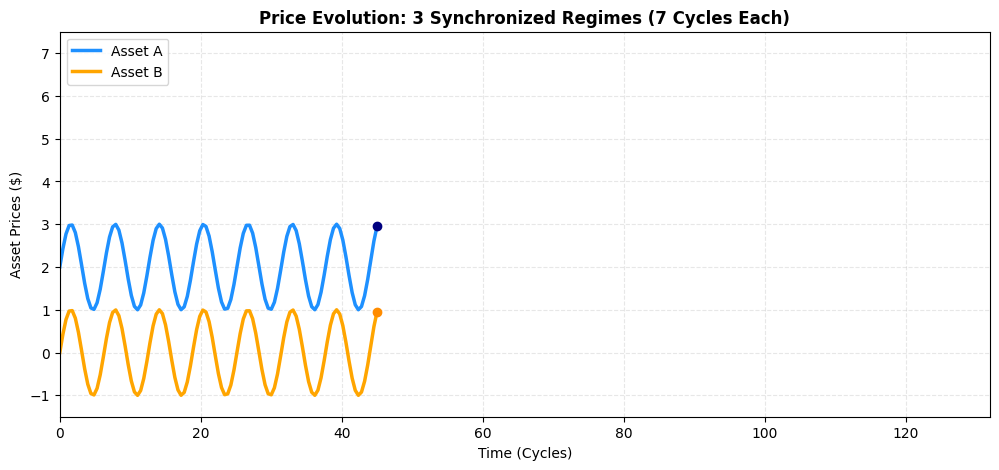


[INFO] Price simulation stopped safely by user.


In [192]:
# 1. Compute the data with 300 frames to make the 21 oscillations look clean
x_simple, asset_A_simple, asset_B_simple = create_pair_multi_oscillations_data(total_frames=300)

# 2. Launch the single-panel animation stream
stream_simple_prices_only(
    x_simple, asset_A_simple, asset_B_simple,
    title="Price Evolution: 3 Synchronized Regimes (7 Cycles Each)"
)


## Regime resilient (with spread)

In [193]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_prices_with_raw_spread(x_space, asset_a_data, asset_b_data, title="Pair Trading Raw Spread Dashboard", interval=15):
    """
    High-performance twin-panel live drawing engine.
    Panel 1: Asset A and Asset B prices across 3 synchronized regimes.
    Panel 2: Raw mathematical spread (A - B) showcasing co-integration stability.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]
    sleep_time = interval / 1000.0

    # Calculate the raw historical spread array
    raw_spread_data = np.array(asset_a_data) - np.array(asset_b_data)

    try:
        while True:
            # 1. PREPARE THE FIGURE FRAMEWORK ONCE (Outside the loop to prevent layout jitter)
            fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

            # Setup Panel 1 (Prices)
            ax1.set_xlim(0, max_x)
            y_min_p = min(min(asset_a_data), min(asset_b_data)) - 0.5
            y_max_p = max(max(asset_a_data), max(asset_b_data)) + 0.5
            ax1.set_ylim(y_min_p, y_max_p)
            ax1.set_title(title, fontsize=12, fontweight="bold")
            ax1.set_ylabel("Asset Prices ($)")
            ax1.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
            ax1.legend(loc="upper left")

            # Setup Panel 2 (Raw Spread)
            ax2.set_xlim(0, max_x)
            # Center the boundaries around the static spread value to keep the line visible
            spread_mean = np.mean(raw_spread_data)
            ax2.set_ylim(spread_mean - 1.5, spread_mean + 1.5)
            ax2.set_title("Mathematical Spread Matrix (Asset A - Asset B)", fontsize=11)
            ax2.set_xlabel("Time (Cycles)")
            ax2.set_ylabel("Spread Value ($)")
            ax2.grid(True, linestyle="--", alpha=0.3)

            # Permanent black equilibrium reference line
            ax2.axhline(spread_mean, color="black", linestyle="-", alpha=0.4)

            line_spread, = ax2.plot([], [], color="purple", linewidth=2, label="Raw Spread")
            tip_spread, = ax2.plot([], [], color="purple", marker="o", markersize=6)
            ax2.legend(loc="upper right")

            # Lock the plot layout sizes before starting vector drawing
            fig.tight_layout()

            x_hist, a_hist, b_hist, s_hist = [], [], [], []

            # 2. FAST ANIMATION LOOP (Blit concept)
            for i in range(total_frames):
                current_x = x_space[i]
                current_a = asset_a_data[i]
                current_b = asset_b_data[i]
                current_s = raw_spread_data[i]

                x_hist.append(current_x)
                a_hist.append(current_a)
                b_hist.append(current_b)
                s_hist.append(current_s)

                # Push coordinate matrix data directly to current graphic layers
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([current_x], [current_a])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([current_x], [current_b])

                line_spread.set_data(x_hist, s_hist)
                tip_spread.set_data([current_x], [current_s])

                clear_output(wait=True)
                display(fig)

                # time.sleep(sleep_time)

            # Master loop delay before clearing current figure structure context
            # time.sleep(0.8)
            plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard simulation stopped safely by user.")
    finally:
        plt.close(fig)


In [194]:
# 1. Re-use our multi-oscillation 3-regime dataset
x_simple, asset_A_simple, asset_B_simple = create_pair_multi_oscillations_data(total_frames=300)

# 2. Run the dynamic twin-panel dashboard
stream_prices_with_raw_spread(
    x_simple, asset_A_simple, asset_B_simple,
    title="Market Shock Analysis: 3-Regime Synchronized Prices & Spread",
    interval=15
)



[INFO] Dashboard simulation stopped safely by user.


## 3-regimes with noise

In [195]:
import numpy as np

def create_pair_noisy_multi_regimes_data(total_frames=300):
    """
    Generates two assets experiencing the exact same 3 market regimes (7 cycles each)
    overlaid with independent random noise to disrupt the perfect sine wave appearance.
    """
    np.random.seed(42) # Ensure reproducible market noise
    max_x = 21 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_bull_run = 7 * 2 * np.pi
    end_bull_run = 14 * 2 * np.pi

    asset_a = np.zeros(total_frames)
    asset_b = np.zeros(total_frames)

    baseline_a = 2.0
    baseline_b = 0.0
    amplitude = 1.0

    slope = (4.0 - 0.0) / (end_bull_run - start_bull_run)

    # Generate independent noise vectors for each asset (standard deviation = 0.12)
    noise_a = np.random.normal(0, 0.12, size=total_frames)
    noise_b = np.random.normal(0, 0.12, size=total_frames)

    for t in range(total_frames):
        x = x_space[t]

        # --- REGIME 1: First 7 stable oscillations + Noise ---
        if x < start_bull_run:
            asset_a[t] = baseline_a + amplitude * np.sin(x) + noise_a[t]
            asset_b[t] = baseline_b + amplitude * np.sin(x) + noise_b[t]

        # --- REGIME 2: Next 7 trend oscillations + Noise ---
        elif start_bull_run <= x < end_bull_run:
            linear_shift = slope * (x - start_bull_run)
            asset_a[t] = baseline_a + linear_shift + amplitude * np.sin(x) + noise_a[t]
            asset_b[t] = baseline_b + linear_shift + amplitude * np.sin(x) + noise_b[t]

        # --- REGIME 3: Final 7 stable oscillations + Noise ---
        else:
            final_shift = slope * (end_bull_run - start_bull_run)
            asset_a[t] = baseline_a + final_shift + amplitude * np.sin(x) + noise_a[t]
            asset_b[t] = baseline_b + final_shift + amplitude * np.sin(x) + noise_b[t]

    return x_space, asset_a, asset_b


In [196]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_prices_with_aligned_spread(x_space, asset_a_data, asset_b_data, title="Pair Trading Aligned Dashboard"):
    """
    High-performance twin-panel live drawing engine with aligned Y-axis scales.
    Fixes the optical illusion by giving Panel 2 the same vertical scale as Panel 1.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]
    raw_spread_data = np.array(asset_a_data) - np.array(asset_b_data)

    # Calculate global minimum and maximum across all price data to standardize axes
    global_y_min = min(min(asset_a_data), min(asset_b_data)) - 0.5
    global_y_max = max(max(asset_a_data), max(asset_b_data)) + 0.5

    try:
        while True:
            fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

            # Panel 1 (Prices Layout) - Standard scale
            ax1.set_xlim(0, max_x)
            ax1.set_ylim(global_y_min, global_y_max)
            ax1.set_title(title, fontsize=12, fontweight="bold")
            ax1.set_ylabel("Asset Prices ($)")
            ax1.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
            tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
            tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
            ax1.legend(loc="upper left")

            # Panel 2 (Raw Spread Layout) - FIX: Forced to share the EXACT same global scale parameters
            ax2.set_xlim(0, max_x)
            ax2.set_ylim(global_y_min, global_y_max)
            ax2.set_title("Mathematical Spread Matrix (Forced Aligned Scale)", fontsize=11)
            ax2.set_xlabel("Time (Cycles)")
            ax2.set_ylabel("Spread Value ($)")
            ax2.grid(True, linestyle="--", alpha=0.3)

            # Draw the static equilibrium line (average spread is around 2.0)
            spread_mean = np.mean(raw_spread_data)
            ax2.axhline(spread_mean, color="black", linestyle="-", alpha=0.4)

            line_spread, = ax2.plot([], [], color="purple", linewidth=2, label="Raw Spread")
            tip_spread, = ax2.plot([], [], color="purple", marker="o", markersize=6)
            ax2.legend(loc="upper right")

            fig.tight_layout()

            x_hist, a_hist, b_hist, s_hist = [], [], [], []

            for i in range(total_frames):
                x_hist.append(x_space[i])
                a_hist.append(asset_a_data[i])
                b_hist.append(asset_b_data[i])
                s_hist.append(raw_spread_data[i])

                # Vector coordinates update mapping
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([x_space[i]], [asset_a_data[i]])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([x_space[i]], [asset_b_data[i]])

                line_spread.set_data(x_hist, s_hist)
                tip_spread.set_data([x_space[i]], [raw_spread_data[i]])

                clear_output(wait=True)
                display(fig)

            plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Simulation stopped safely by user.")
    finally:
        plt.close(fig)


In [197]:
# 1. Generate the same noisy market dataset
x_noisy, asset_A_noisy, asset_B_noisy = create_pair_noisy_multi_regimes_data(total_frames=300)

# 2. Run the simulation with identical visual weights
stream_prices_with_aligned_spread(
    x_noisy, asset_A_noisy, asset_B_noisy,
    title="Noisy Cointégration: Aligned Scale Demonstration"
)



[INFO] Simulation stopped safely by user.


# Introducing hedge ratio

In [198]:
import numpy as np

def create_asymmetric_pair_data(total_frames=200):
    """
    Generates two in-phase assets where Asset A has exactly twice
    the oscillation amplitude of Asset B (the reference).
    """
    # 10 full cycles = 10 * 2 * pi
    max_x = 10 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # Asset B (The Reference): Amplitude = 1.0, Baseline = 0.0
    asset_b = 0.0 + 1.0 * np.sin(x_space)

    # Asset A: Amplitude = 2.0 (Twice Asset B), Baseline = 4.0 (to separate them vertically)
    asset_a = 4.0 + 2.0 * np.sin(x_space)

    return x_space, asset_a, asset_b


In [199]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_asymmetric_pair_analysis(x_space, asset_a_data, asset_b_data, title="Asymmetric Amplitude Analysis"):
    """
    High-performance twin-panel engine for asymmetric pair trading.
    Panel 2 features a perfectly centered Y-axis scale around the equilibrium point (4.0).
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    # Pre-compute the two types of spreads
    raw_spread = np.array(asset_a_data) - np.array(asset_b_data)
    beta_adjusted_spread = np.array(asset_a_data) - (2.0 * np.array(asset_b_data))

    try:
        while True:
            fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

            # Panel 1: Prices Setup
            ax1.set_xlim(0, max_x)
            ax1.set_ylim(-2.0, 7.0)
            ax1.set_title(title, fontsize=12, fontweight="bold")
            ax1.set_ylabel("Asset Prices ($)")
            ax1.grid(True, linestyle="--", alpha=0.3)

            line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A (2x Amp)")
            tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
            line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B (1x Amp / Ref)")
            tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
            ax1.legend(loc="upper left")

            # Panel 2: Spreads Evaluation Setup
            ax2.set_xlim(0, max_x)

            # FIX: Force a perfectly centered Y-axis around the 4.0 equilibrium baseline
            # (4.0 is the exact center of both the green line and the purple wave)
            ax2.set_ylim(2.5, 5.5)

            ax2.set_title("Spread Metrics: Raw vs Beta-Adjusted (Hedged) Comparison", fontsize=11)
            ax2.set_xlabel("Time (Cycles)")
            ax2.set_ylabel("Spread Value ($)")
            ax2.grid(True, linestyle="--", alpha=0.3)

            # Permanent black equilibrium reference line right in the middle (at 4.0)
            ax2.axhline(4.0, color="black", linestyle="-", alpha=0.4)

            # Labels and placeholders for the two concurrent spreads
            line_raw, = ax2.plot([], [], color="purple", linewidth=2, linestyle=":", label="Raw Spread (A - B) -> Fails")
            tip_raw, = ax2.plot([], [], color="purple", marker="o", markersize=5)

            line_adj, = ax2.plot([], [], color="green", linewidth=2.5, label="Hedged Spread (A - 2*B) -> Stable")
            tip_adj, = ax2.plot([], [], color="darkgreen", marker="o", markersize=6)
            ax2.legend(loc="upper right")

            fig.tight_layout()

            x_hist, a_hist, b_hist, r_hist, adj_hist = [], [], [], [], []

            for i in range(total_frames):
                x_hist.append(x_space[i])
                a_hist.append(asset_a_data[i])
                b_hist.append(asset_b_data[i])
                r_hist.append(raw_spread[i])
                adj_hist.append(beta_adjusted_spread[i])

                # Push twin layers matrix updates instantly
                line_a.set_data(x_hist, a_hist)
                tip_a.set_data([x_space[i]], [asset_a_data[i]])
                line_b.set_data(x_hist, b_hist)
                tip_b.set_data([x_space[i]], [asset_b_data[i]])

                line_raw.set_data(x_hist, r_hist)
                tip_raw.set_data([x_space[i]], [raw_spread[i]])

                line_adj.set_data(x_hist, adj_hist)
                tip_adj.set_data([x_space[i]], [beta_adjusted_spread[i]])

                clear_output(wait=True)
                display(fig)

            plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Simulation stopped safely by user.")
    finally:
        plt.close(fig)


In [200]:
# 1. Compute the asymmetric 10-cycle data vectors
x_asym, asset_A_asym, asset_B_asym = create_asymmetric_pair_data(total_frames=200)

# 2. Launch the comparison dashboard with the new centered scale
stream_asymmetric_pair_analysis(
    x_asym, asset_A_asym, asset_B_asym,
    title="Beta Weighting Demonstration: Handling 2x Amplitude Mismatch"
)



[INFO] Simulation stopped safely by user.


## Pair-Trading Anomalies

In [201]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

def stream_perfect_arbitrage_with_bot_exit(x_space, asset_a_data, asset_b_data):
    """
    High-performance twin-panel live drawing engine with zero sleep delay.
    Panel 1: Yellow fills are 100% geometric and autonomous (active when Asset A exits 3.0/4.0).
    Panel 2: Bot trades the true raw spread, entering at triggers (+/-0.45 from mean)
             and strictly exiting only when the spread returns to the baseline mean (3.0).
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    # True mathematical point-by-point spread tracking
    raw_spread = np.array(asset_a_data) - np.array(asset_b_data)
    spread_center = 3.0

    # Prepare persistent clean canvas architecture once to prevent jitter
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

    # Panel 1 Layout
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 5.5)
    ax1.set_title("Asset Quotes Matrix: Geometric Anomalies & Price Oscillations", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.axhline(4.0, color="gray", linestyle="--", alpha=0.5)
    ax1.axhline(3.0, color="gray", linestyle="--", alpha=0.5)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
    line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
    ax1.legend(loc="upper left")

    # Panel 2 Layout
    ax2.set_xlim(0, max_x)
    ax2.set_ylim(1.0, 5.0)
    ax2.set_title("Arbitrage Window: True Raw Price Spread with Target Mean Exits", fontsize=11)
    ax2.set_xlabel("Time (Cycles)")
    ax2.set_ylabel("Spread Value ($)")
    ax2.grid(True, linestyle="--", alpha=0.3)

    ax2.axhline(spread_center + 0.45, color="gray", linestyle="--", alpha=0.5, label="Sell Trigger (3.45)")
    ax2.axhline(spread_center, color="black", linestyle="-", alpha=0.4)
    ax2.axhline(spread_center - 0.45, color="gray", linestyle="--", alpha=0.5, label="Buy Trigger (2.55)")
    ax2.legend(loc="upper right")

    line_spread, = ax2.plot([], [], color="purple", linewidth=2.5)
    tip_spread, = ax2.plot([], [], color="purple", marker="o", markersize=6)

    fig.tight_layout()

    # Shared historical tracking arrays
    x_hist, a_hist, b_hist, s_hist = [], [], [], []

    # Active single-frame collections placeholder to prevent multi-fill memory leaks
    current_fills = []

    # Bot State Tracking Registers
    in_trade = False
    trade_type = None # "buy" or "sell"
    t_x, t_s = [], []
    waiting_for_cooldown = False

    # Permanent historical archive for closed bot trades
    past_bot_trades = [] # elements: (x_slice, s_slice, color)

    try:
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_data[i]
            cb = asset_b_data[i]
            cs = raw_spread[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)
            s_hist.append(cs)

            x_arr = np.array(x_hist)
            a_arr = np.array(a_hist)

            # --- BOT TRADING LOGIC WITH BASELINE EXITS ---
            if waiting_for_cooldown:
                # Cool down clears when spread stays inside safety band
                if (spread_center - 0.1) <= cs <= (spread_center + 0.1):
                    waiting_for_cooldown = False

            if not waiting_for_cooldown and not in_trade:
                # Entry triggers
                if cs <= 2.55:
                    in_trade = True
                    trade_type = "buy"
                    t_x, t_s = [cx], [cs]
                elif cs >= 3.45:
                    in_trade = True
                    trade_type = "sell"
                    t_x, t_s = [cx], [cs]
            elif in_trade:
                t_x.append(cx)
                t_s.append(cs)

                # STRICT EXIT TRIGGER: Closed ONLY when spread reaches back to 3.0 mean baseline
                if (trade_type == "buy" and cs >= spread_center) or (trade_type == "sell" and cs <= spread_center):
                    trade_color = "lightgreen" if trade_type == "buy" else "coral"
                    past_bot_trades.append((list(t_x), list(t_s), trade_color))

                    in_trade = False
                    trade_type = None
                    t_x, t_s = [], []
                    waiting_for_cooldown = True

            # --- CLEAN LAYER REPAINT ENGINE ---
            # Remove previous frame's color fills to ensure no opacity stacking
            while len(current_fills) > 0:
                current_fills.pop().remove()

            # 1. PANEL 1: PURE GEOMETRIC YELLOW FILLS (100% Autonomous, strictly outside bounds)
            f_yellow_low = ax1.fill_between(x_arr, a_arr, 3.0, where=(a_arr < 3.0), color="gold", alpha=0.4)
            f_yellow_high = ax1.fill_between(x_arr, a_arr, 4.0, where=(a_arr > 4.0), color="gold", alpha=0.4)
            current_fills.extend([f_yellow_low, f_yellow_high])

            # 2. PANEL 2: REPAINT CLOSED BOT TRADES
            for tx, ts, col in past_bot_trades:
                f_past = ax2.fill_between(tx, ts, spread_center, color=col, alpha=0.5)
                current_fills.append(f_past)

            # 3. PANEL 2: RENDER CURRENT LIVE OPEN BOT TRADE
            if in_trade:
                col = "lightgreen" if trade_type == "buy" else "coral"
                f_live = ax2.fill_between(t_x, t_s, spread_center, color=col, alpha=0.5)
                current_fills.append(f_live)

            # Refresh line structures coordinates
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])
            line_spread.set_data(x_hist, s_hist)
            tip_spread.set_data([cx], [cs])

            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Simulation stopped safely by user.")
    finally:
        plt.close(fig)


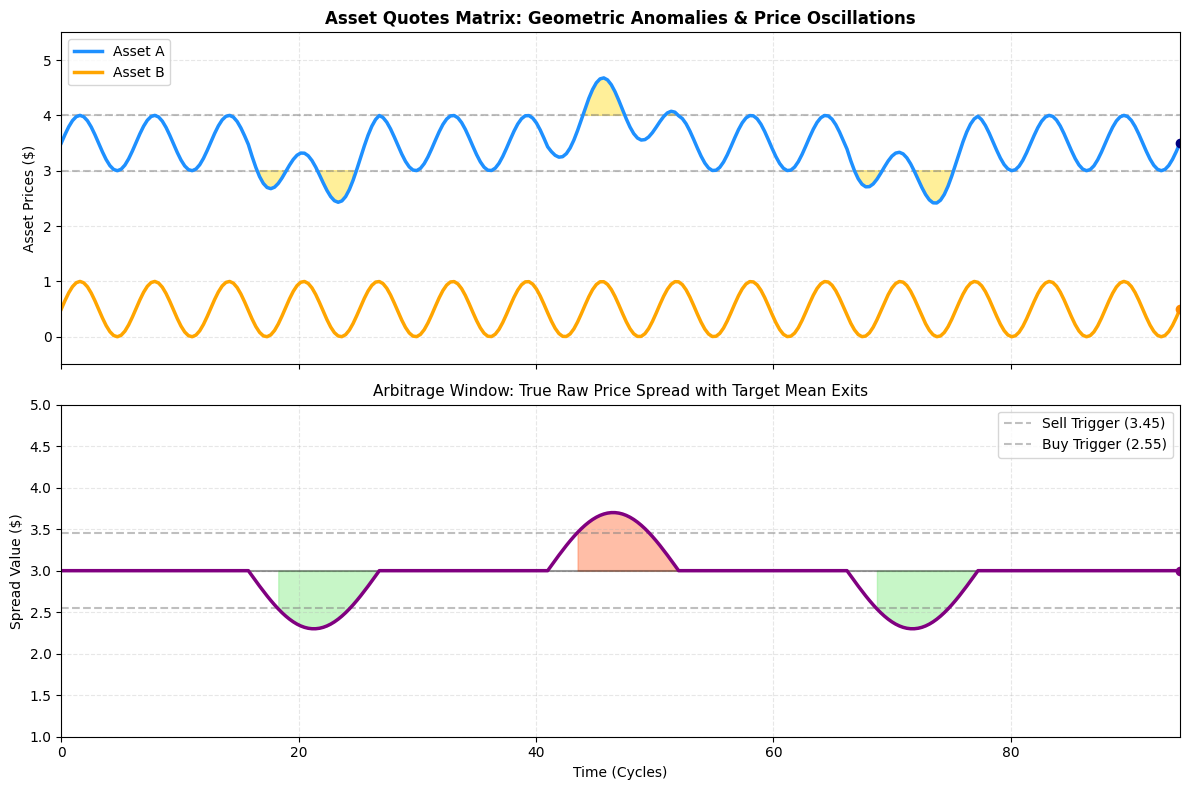

In [202]:
# 1. Compute the true organic co-integrated forex vectors (3 anomalies)
x_data, asset_A_real, asset_B_real = create_real_pairs_anomalies(total_frames=300)

# 2. Launch the dynamic dashboard at raw CPU processing speed
stream_perfect_arbitrage_with_bot_exit(x_data, asset_A_real, asset_B_real)


## Z-Score spread

In [203]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

def stream_zscore_arbitrage_with_bot_exit(x_space, asset_a_data, asset_b_data):
    """
    High-performance live drawing engine with a perfectly calibrated Z-Score.
    Fixed the baseline bias bug by using the true statistical parameters of the stable regime.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    # 1. RIGOROUS CALIBRATION FIX:
    # To keep Z-Score at exactly 0.0 during calm periods, we use the true stable parameters.
    # Mean baseline distance is 3.0, and the clean amplitude deviation is 0.5.
    raw_spread = np.array(asset_a_data) - np.array(asset_b_data)
    true_stable_mean = 3.0
    true_stable_std = 0.5

    # Perfect mathematical Z-Score alignment
    zscore_data = (raw_spread - true_stable_mean) / true_stable_std

    # Prepare persistent clean canvas architecture once to prevent jitter
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

    # Panel 1 Layout (Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 5.5)
    ax1.set_title("Asset Quotes Matrix: Geometric Anomalies & Price Oscillations", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.axhline(4.0, color="gray", linestyle="--", alpha=0.5)
    ax1.axhline(3.0, color="gray", linestyle="--", alpha=0.5)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
    line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
    ax1.legend(loc="upper left")

    # Panel 2 Layout (Centered-Reduced Z-Score Spread)
    ax2.set_xlim(0, max_x)
    ax2.set_ylim(-2.5, 2.5)
    ax2.set_title("Arbitrage Window: Centered-Reduced Spread (Z-Score) with Target Zero Exits", fontsize=11)
    ax2.set_xlabel("Time (Cycles)")
    ax2.set_ylabel("Z-Score")
    ax2.grid(True, linestyle="--", alpha=0.3)

    # Standardized Statistical Thresholds
    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Sell Trigger (1.0)")
    ax2.axhline(0.0, color="black", linestyle="-", alpha=0.4) # Zero baseline center
    ax2.axhline(-1.0, color="gray", linestyle="--", alpha=0.5, label="Buy Trigger (-1.0)")
    ax2.legend(loc="upper right")

    line_zscore, = ax2.plot([], [], color="purple", linewidth=2.5)
    tip_zscore, = ax2.plot([], [], color="purple", marker="o", markersize=6)

    fig.tight_layout()

    # Shared historical tracking arrays
    x_hist, a_hist, b_hist, z_hist = [], [], [], []

    # Active single-frame collections placeholder to prevent multi-fill memory leaks
    current_fills = []

    # Bot State Tracking Registers
    in_trade = False
    trade_type = None # "buy" or "sell"
    t_x, t_z = [], []
    waiting_for_cooldown = False

    # Permanent historical archive for closed bot trades
    past_bot_trades = [] # elements: (x_slice, z_slice, color)

    try:
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_data[i]
            cb = asset_b_data[i]
            cz = zscore_data[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)
            z_hist.append(cz)

            x_arr = np.array(x_hist)
            a_arr = np.array(a_hist)

            # --- BOT TRADING LOGIC WITH ZERO MEAN EXITS ---
            if waiting_for_cooldown:
                # Tolerance buffer to reset cooldown safely close to zero
                if -0.05 <= cz <= 0.05:
                    waiting_for_cooldown = False

            if not waiting_for_cooldown and not in_trade:
                # Standardized triggers entries (Trigger at absolute +/- 1.0)
                if cz <= -1.0:
                    in_trade = True
                    trade_type = "buy"
                    t_x, t_z = [cx], [cz]
                elif cz >= 1.0:
                    in_trade = True
                    trade_type = "sell"
                    t_x, t_z = [cx], [cz]
            elif in_trade:
                t_x.append(cx)
                t_z.append(cz)

                # STRICT EXIT TRIGGER: Closed ONLY when Z-score returns to the absolute 0.0 line
                if (trade_type == "buy" and cz >= 0.0) or (trade_type == "sell" and cz <= 0.0):
                    trade_color = "lightgreen" if trade_type == "buy" else "coral"
                    past_bot_trades.append((list(t_x), list(t_z), trade_color))

                    in_trade = False
                    trade_type = None
                    t_x, t_z = [], []
                    waiting_for_cooldown = True

            # --- CLEAN LAYER REPAINT ENGINE ---
            while len(current_fills) > 0:
                current_fills.pop().remove()

            # 1. PANEL 1: PURE GEOMETRIC YELLOW FILLS (Autonomous outside bounds)
            f_yellow_low = ax1.fill_between(x_arr, a_arr, 3.0, where=(a_arr < 3.0), color="gold", alpha=0.4)
            f_yellow_high = ax1.fill_between(x_arr, a_arr, 4.0, where=(a_arr > 4.0), color="gold", alpha=0.4)
            current_fills.extend([f_yellow_low, f_yellow_high])

            # 2. PANEL 2: REPAINT CLOSED BOT TRADES (Fills down to the 0.0 baseline)
            for tx, tz, col in past_bot_trades:
                f_past = ax2.fill_between(tx, tz, 0, color=col, alpha=0.5)
                current_fills.append(f_past)

            # 3. PANEL 2: RENDER CURRENT LIVE OPEN BOT TRADE
            if in_trade:
                col = "lightgreen" if trade_type == "buy" else "coral"
                f_live = ax2.fill_between(t_x, t_z, 0, color=col, alpha=0.5)
                current_fills.append(f_live)

            # Refresh line structures coordinates
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])
            line_zscore.set_data(x_hist, z_hist)
            tip_zscore.set_data([cx], [cz])

            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Simulation stopped safely by user.")
    finally:
        plt.close(fig)


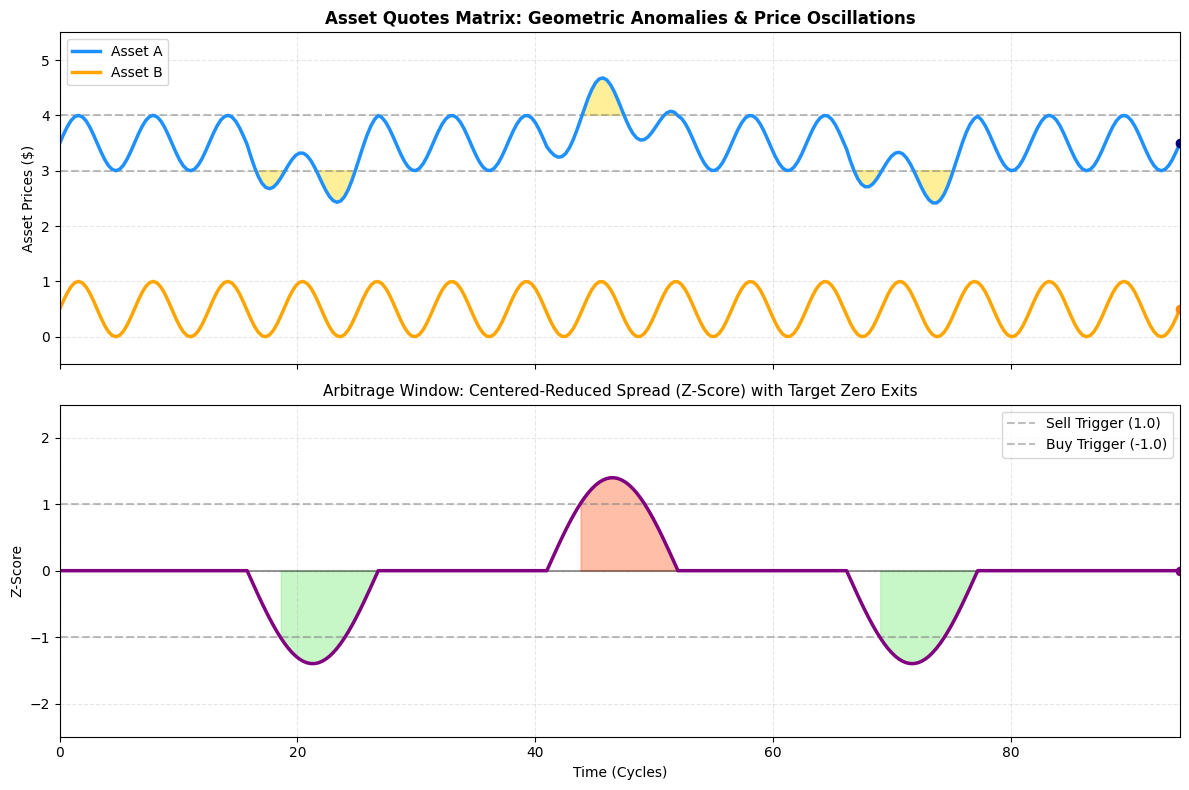

In [206]:
# 1. Generate the raw pairs data vectors
x_data, asset_A_real, asset_B_real = create_real_pairs_anomalies(total_frames=300)

# 2. Launch the dynamic centered-reduced simulation dashboard
stream_zscore_arbitrage_with_bot_exit(x_data, asset_A_real, asset_B_real)


## Co-integration breakout

In [207]:
import numpy as np

def create_broken_cointegration_dataset(total_frames=300):
    """
    Generates two synchronized assets where Asset A experiences a permanent
    structural breakdown at the halfway mark, completely destroying the co-integration.
    """
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    baseline_a = 3.5
    baseline_b = 0.5
    amplitude = 0.5

    # Base pure synchronized waves
    asset_a = baseline_a + amplitude * np.sin(x_space)
    asset_b = baseline_b + amplitude * np.sin(x_space)

    halfway_idx = total_frames // 2

    # Inject the permanent structural break from the halfway point until the end
    for t in range(total_frames):
        if t >= halfway_idx:
            # Asset A completely detaches from its twin and drops linearly down towards 0.0
            steps_passed = t - halfway_idx
            total_trend_steps = total_frames - halfway_idx
            linear_drop = 3.5 * (steps_passed / total_trend_steps)

            # Asset A fades out its sine wave and collapses downward
            asset_a[t] = (baseline_a - linear_drop) + 0.1 * np.sin(x_space[t])

    return x_space, asset_a, asset_b


In [208]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

def stream_broken_cointegration_dashboard(x_space, asset_a_data, asset_b_data):
    """
    High-performance live drawing engine showcasing a permanent co-integration break.
    Demonstrates how the Z-Score breaks its 0.0 baseline permanently, trapping the bot.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    # Calculate Z-Score calibrated on the initial stable parameters (mean=3.0, std=0.5)
    raw_spread = np.array(asset_a_data) - np.array(asset_b_data)
    true_stable_mean = 3.0
    true_stable_std = 0.5
    zscore_data = (raw_spread - true_stable_mean) / true_stable_std

    # Prepare canvas layout
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

    # Panel 1 Layout (Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 5.5)
    ax1.set_title("Asset Quotes Matrix: Permanent Structural Break (Co-integration Loss)", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.axhline(4.0, color="gray", linestyle="--", alpha=0.5)
    ax1.axhline(3.0, color="gray", linestyle="--", alpha=0.5)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="Asset A")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=6)
    line_b, = ax1.plot([], [], color="orange", linewidth=2.5, label="Asset B")
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
    ax1.legend(loc="lower left")

    # Panel 2 Layout (Z-Score Breakdown View)
    ax2.set_xlim(0, max_x)
    ax2.set_ylim(-4.5, 2.5) # Expanded lower bound to capture the massive Z-score drop
    ax2.set_title("Arbitrage Window: Endless Position Trap (Z-Score never returns to 0.0)", fontsize=11, color="crimson")
    ax2.set_xlabel("Time (Cycles)")
    ax2.set_ylabel("Z-Score")
    ax2.grid(True, linestyle="--", alpha=0.3)

    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
    ax2.axhline(0.0, color="black", linestyle="-", alpha=0.4)
    ax2.axhline(-1.0, color="gray", linestyle="--", alpha=0.5, label="Buy Trigger (-1.0)")
    ax2.legend(loc="upper right")

    line_zscore, = ax2.plot([], [], color="purple", linewidth=2.5)
    tip_zscore, = ax2.plot([], [], color="purple", marker="o", markersize=6)

    fig.tight_layout()

    x_hist, a_hist, b_hist, z_hist = [], [], [], []
    current_fills = []

    # Trading states
    in_trade = False
    t_x, t_z = [], []

    try:
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_data[i]
            cb = asset_b_data[i]
            cz = zscore_data[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)
            z_hist.append(cz)

            x_arr = np.array(x_hist)
            a_arr = np.array(a_hist)

            # --- TRADING LOGIC: ENTER AND GET TRAPPED ---
            if not in_trade:
                if cz <= -1.0:
                    in_trade = True
                    t_x, t_z = [cx], [cz]
            else:
                t_x.append(cx)
                t_z.append(cz)
                # EXIT IS IMPOSSIBLE: cz will never go back above 0.0!

            # --- CLEAN LAYER REPAINT ENGINE ---
            while len(current_fills) > 0:
                current_fills.pop().remove()

            # 1. Autonomous Geometric Fills (strictly outside tunnel)
            f_yellow_low = ax1.fill_between(x_arr, a_arr, 3.0, where=(a_arr < 3.0), color="gold", alpha=0.4)
            f_yellow_high = ax1.fill_between(x_arr, a_arr, 4.0, where=(a_arr > 4.0), color="gold", alpha=0.4)
            current_fills.extend([f_yellow_low, f_yellow_high])

            # 2. Render the endless active open trade fill layer
            if in_trade:
                f_live = ax2.fill_between(t_x, t_z, 0, color="lightgreen", alpha=0.5)
                current_fills.append(f_live)

            # Vector updates
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])
            line_zscore.set_data(x_hist, z_hist)
            tip_zscore.set_data([cx], [cz])

            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Simulation stopped safely by user.")
    finally:
        plt.close(fig)


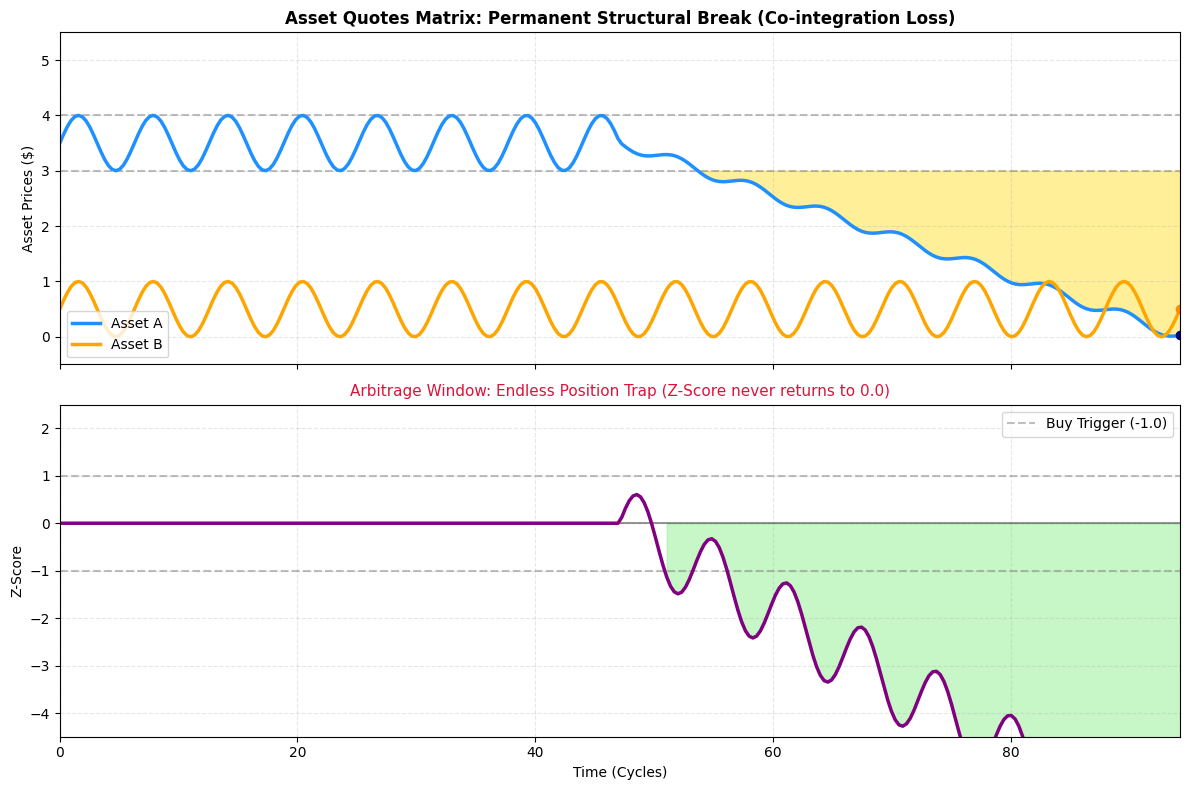

In [209]:
# 1. Compute the structural break dataset
x_break, asset_A_break, asset_B_break = create_broken_cointegration_dataset(total_frames=300)

# 2. Launch the dynamic dashboard
stream_broken_cointegration_dashboard(x_break, asset_A_break, asset_B_break)


# Choke Resilient

In [210]:
import numpy as np

def create_macro_pair_with_anomalies(total_frames=300):
    """
    Simulates EUR/USD (Asset B) and GBP/USD (Asset A) under a massive Dollar Crash (USD Index).
    Both currencies skyrocket due to the macro shock, but Asset A experiences
    3 micro-anomalies along the way, testing the bot's market-neutral insulation.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    start_usd_drop = int(total_frames * 0.35)
    end_usd_drop = int(total_frames * 0.65)

    gbp_usd = np.zeros(total_frames)
    eur_usd = np.zeros(total_frames)
    usd_index = np.zeros(total_frames)

    # Base structure parameters
    baseline_gbp = 3.5
    baseline_eur = 0.5
    amplitude = 0.5

    usd_start_val = 100.0
    usd_end_val = 40.0
    slope_usd = (usd_end_val - usd_start_val) / (end_usd_drop - start_usd_drop)
    slope_market_climb = 3.0 / (end_usd_drop - start_usd_drop)

    for t in range(total_frames):
        x = x_space[t]

        # --- COMPUTE COMMON MACRO TREND (THE DOLLAR SHOCK) ---
        if t < start_usd_drop:
            usd_index[t] = usd_start_val
            current_trend_shift = 0.0
        elif start_usd_drop <= t < end_usd_drop:
            steps = t - start_usd_drop
            usd_index[t] = usd_start_val + (slope_usd * steps)
            current_trend_shift = slope_market_climb * steps
        else:
            usd_index[t] = usd_end_val
            current_trend_shift = 3.0

        # --- GENERATE SYNCHRONIZED BASES ---
        gbp_usd[t] = baseline_gbp + current_trend_shift + amplitude * np.sin(x)
        eur_usd[t] = baseline_eur + current_trend_shift + amplitude * np.sin(x)

        # --- INJECT MICRO ANOMALIES ON ASSET A ONLY ---
        # Anomaly 1 (BUY): Drop between frames 40 and 75
        if 40 <= t < 75:
            factor = np.sin(np.pi * (t - 40) / 35)
            gbp_usd[t] -= 0.7 * factor
        # Anomaly 2 (SELL): Spike between frames 120 and 155
        elif 120 <= t < 155:
            factor = np.sin(np.pi * (t - 120) / 35)
            gbp_usd[t] += 0.7 * factor
        # Anomaly 3 (BUY): Drop between frames 210 and 245
        elif 210 <= t < 245:
            factor = np.sin(np.pi * (t - 210) / 35)
            gbp_usd[t] -= 0.7 * factor

    return x_space, gbp_usd, eur_usd, usd_index


In [211]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

def stream_macro_insulated_arbitrage(x_space, gbp_data, eur_data, usd_data):
    """
    High-performance live drawing engine with zero sleep delay.
    Panel 1 uses twinx() to show a collapsing Dollar Index while Asset A's boundaries climb dynamically.
    Panel 2 displays a perfectly flat calibrated Z-Score capturing profits despite the macro storm.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    start_usd_drop = int(total_frames * 0.35)
    end_usd_drop = int(total_frames * 0.65)
    slope_market_climb = 3.0 / (end_usd_drop - start_usd_drop)

    # Calibrated Z-Score metrics (equilibrium distance = 3.0, clean standard deviation = 0.5)
    raw_spread = np.array(gbp_data) - np.array(eur_data)
    zscore_data = (raw_spread - 3.0) / 0.5

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)

    # Panel 1 Config (Prices Left Y-Axis)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, 8.5) # Expanded for the upward climb
    ax1.set_ylabel("Currency Prices ($)", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_gbp, = ax1.plot([], [], color="dodgerblue", linewidth=2.5, label="GBP/USD (A)")
    tip_gbp, = ax1.plot([], [], color="navy", marker="o", markersize=6)
    line_eur, = ax1.plot([], [], color="orange", linewidth=2.5, label="EUR/USD (B)")
    tip_eur, = ax1.plot([], [], color="darkorange", marker="o", markersize=6)
    ax1.legend(loc="upper left")

    # Dynamic trend boundary guidelines handles
    upper_bound_line, = ax1.plot([], [], color="gray", linestyle="--", alpha=0.4)
    lower_bound_line, = ax1.plot([], [], color="gray", linestyle="--", alpha=0.4)

    # Panel 1 Right Y-Axis (USD Index Twinx)
    ax_usd = ax1.twinx()
    ax_usd.set_ylim(30.0, 110.0)
    ax_usd.set_ylabel("US Dollar Index (USDX)", color="crimson", fontweight="bold")
    ax_usd.tick_params(axis='y', labelcolor="crimson")
    line_usd, = ax_usd.plot([], [], color="crimson", linewidth=2, linestyle="-.", label="USD Index")
    ax_usd.legend(loc="lower left")

    # Panel 2 Config (Z-Score)
    ax2.set_xlim(0, max_x)
    ax2.set_ylim(-2.5, 2.5)
    ax2.set_title("Arbitrage Window: Centered-Reduced Spread (Z-Score) Neutral to USD Shock", fontsize=11)
    ax2.set_xlabel("Time (Cycles)")
    ax2.set_ylabel("Z-Score")
    ax2.grid(True, linestyle="--", alpha=0.3)

    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Sell Trigger (1.0)")
    ax2.axhline(0.0, color="black", linestyle="-", alpha=0.4)
    ax2.axhline(-1.0, color="gray", linestyle="--", alpha=0.5, label="Buy Trigger (-1.0)")
    ax2.legend(loc="upper right")

    line_zscore, = ax2.plot([], [], color="purple", linewidth=2.5)
    tip_zscore, = ax2.plot([], [], color="purple", marker="o", markersize=6)

    fig.tight_layout()

    # Shared histories
    x_hist, g_hist, e_hist, u_hist, z_hist = [], [], [], [], []
    upper_bounds_hist, lower_bounds_hist = [], []
    current_fills = []

    in_trade = False
    trade_type = None
    t_x, t_z = [], []
    waiting_for_cooldown = False
    past_bot_trades = []

    try:
        for i in range(total_frames):
            cx = x_space[i]
            cg = gbp_data[i]
            ce = eur_data[i]
            cu = usd_data[i]
            cz = zscore_data[i]

            x_hist.append(cx)
            g_hist.append(cg)
            e_hist.append(ce)
            u_hist.append(cu)
            z_hist.append(cz)

            # Compute dynamic baseline rails history for the yellow mask
            if i < start_usd_drop:
                shift = 0.0
            elif start_usd_drop <= i < end_usd_drop:
                shift = slope_market_climb * (i - start_usd_drop)
            else:
                shift = 3.0

            current_upper = 4.0 + shift
            current_lower = 3.0 + shift
            upper_bounds_hist.append(current_upper)
            lower_bounds_hist.append(current_lower)

            x_arr = np.array(x_hist)
            g_arr = np.array(g_hist)
            up_arr = np.array(upper_bounds_hist)
            lo_arr = np.array(lower_bounds_hist)

            # --- BOT TRADING ENGINE LOGIC ---
            if waiting_for_cooldown:
                if -0.05 <= cz <= 0.05:
                    waiting_for_cooldown = False

            if not waiting_for_cooldown and not in_trade:
                if cz <= -1.0:
                    in_trade = True
                    trade_type = "buy"
                    t_x, t_z = [cx], [cz]
                elif cz >= 1.0:
                    in_trade = True
                    trade_type = "sell"
                    t_x, t_z = [cx], [cz]
            elif in_trade:
                t_x.append(cx)
                t_z.append(cz)
                if (trade_type == "buy" and cz >= 0.0) or (trade_type == "sell" and cz <= 0.0):
                    trade_color = "lightgreen" if trade_type == "buy" else "coral"
                    past_bot_trades.append((list(t_x), list(t_z), trade_color))
                    in_trade = False
                    trade_type = None
                    t_x, t_z = [], []
                    waiting_for_cooldown = True

            # --- GEOMETRIC FILL REDRAW REPAINT ---
            while len(current_fills) > 0:
                current_fills.pop().remove()

            # 1. Panel 1: Geometric yellow fills clipped dynamically tracking the sloped tunnels
            f_y_low = ax1.fill_between(x_arr, g_arr, lo_arr, where=(g_arr < lo_arr), color="gold", alpha=0.4)
            f_y_high = ax1.fill_between(x_arr, g_arr, up_arr, where=(g_arr > up_arr), color="gold", alpha=0.4)
            current_fills.extend([f_y_low, f_y_high])

            # 2. Panel 2: Repaint history + active trade
            for tx, tz, col in past_bot_trades:
                f_past = ax2.fill_between(tx, tz, 0, color=col, alpha=0.5)
                current_fills.append(f_past)
            if in_trade:
                col = "lightgreen" if trade_type == "buy" else "coral"
                f_live = ax2.fill_between(t_x, t_z, 0, color=col, alpha=0.5)
                current_fills.append(f_live)

            # Refresh coordinates references
            line_gbp.set_data(x_hist, g_hist)
            tip_gbp.set_data([cx], [cg])
            line_eur.set_data(x_hist, e_hist)
            tip_eur.set_data([cx], [ce])
            line_usd.set_data(x_hist, u_hist)
            upper_bound_line.set_data(x_hist, upper_bounds_hist)
            lower_bound_line.set_data(x_hist, lower_bounds_hist)

            line_zscore.set_data(x_hist, z_hist)
            tip_zscore.set_data([cx], [cz])

            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Simulation stopped safely by user.")
    finally:
        plt.close(fig)


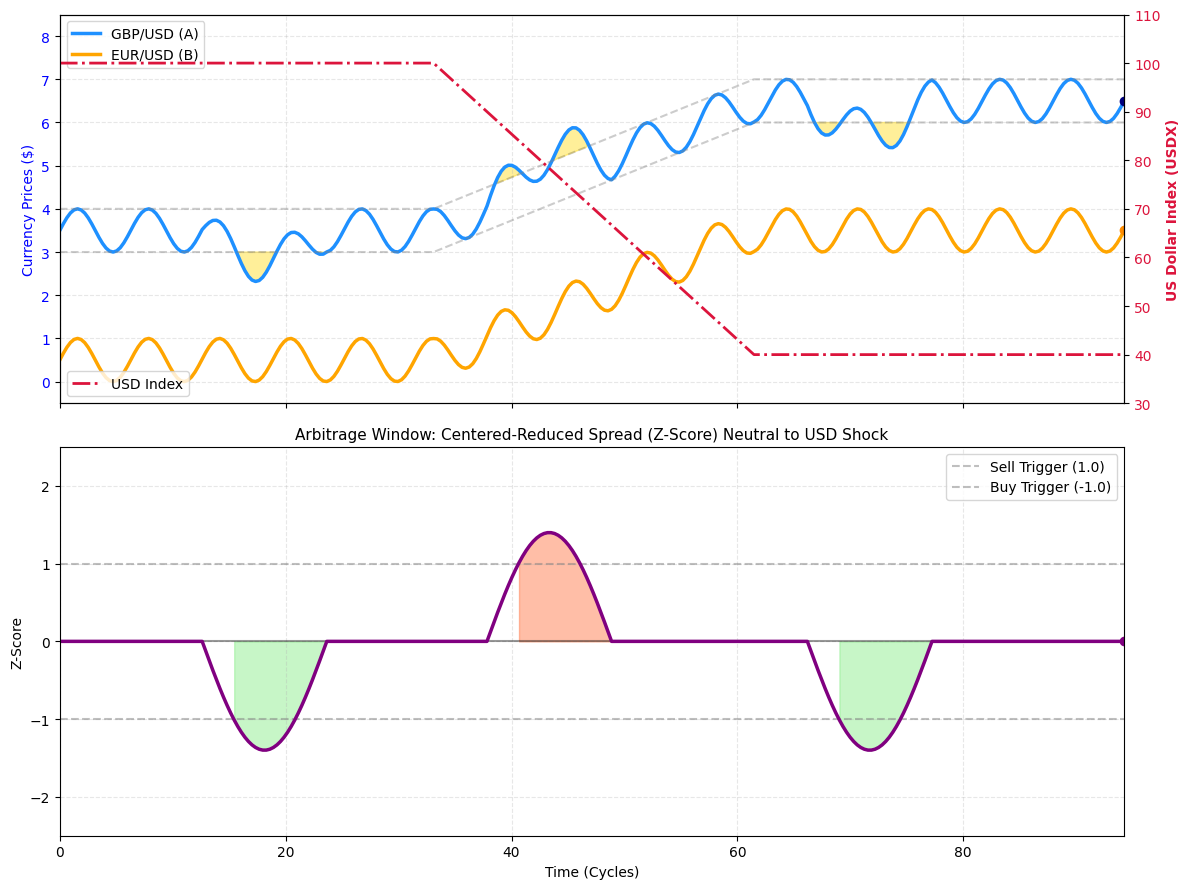

In [214]:
# 1. Compute the macro dataset with 3 embedded anomalies (300 frames)
x_forex, gbp_rates, eur_rates, dxy_index = create_macro_pair_with_anomalies(total_frames=300)

# 2. Launch the dynamic dashboard at full processor speed
stream_macro_insulated_arbitrage(x_forex, gbp_rates, eur_rates, dxy_index)
